In [2]:
print("SME Payment Risk Analytics")
print("Jupyter is working!")

SME Payment Risk Analytics
Jupyter is working!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import sqlalchemy

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("SQLAlchemy:", sqlalchemy.__version__)

Pandas: 3.0.5
NumPy: 2.4.6
Scikit-learn: 1.9.0
SQLAlchemy: 2.0.52


In [4]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password="Mypassword",
    host="localhost",
    port=5432,
    database="sme_payment_risk"
)

engine = create_engine(connection_url)

print("Database connection configured.")

Database connection configured.


In [5]:
from sqlalchemy import text

with engine.connect() as connection:
    result = connection.execute(text("SELECT version();"))
    print(result.fetchone()[0])

PostgreSQL 18.4 on x86_64-windows, compiled by msvc-19.44.35227, 64-bit


In [6]:
import pandas as pd

df = pd.read_csv('../data/raw/dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (50000, 19)


,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,area_business,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
0,U001,200769623,WAL-MAR corp,11-02-2020 00:00,2020,1930438491,26-01-2020,20200125,20200126,20200210,USD,RV,1,NaN,54273.28,20200126,NAH4,1.930438e+09,0
1,U001,200980828,BEN E,08-08-2019 00:00,2019,1929646410,22-07-2019,20190722,20190722,20190811,USD,RV,1,NaN,79656.60,20190722,NAD1,1.929646e+09,0
2,U001,200792734,MDV/ trust,30-12-2019 00:00,2019,1929873765,14-09-2019,20190914,20190914,20190929,USD,RV,1,NaN,2253.86,20190914,NAA8,1.929874e+09,0
3,CA02,140105686,SYSC llc,NaN,2020,2960623488,30-03-2020,20200330,20200330,20200410,CAD,RV,1,NaN,3299.70,20200331,CA10,2.960623e+09,1
4,U001,200769623,WAL-MAR foundation,25-11-2019 00:00,2019,1930147974,13-11-2019,20191113,20191113,20191128,USD,RV,1,NaN,33133.29,20191113,NAH4,1.930148e+09,0


In [7]:
df.head(5)

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,area_business,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
0,U001,200769623,WAL-MAR corp,11-02-2020 00:00,2020,1930438491,26-01-2020,20200125,20200126,20200210,USD,RV,1,NaN,54273.28,20200126,NAH4,1.930438e+09,0
1,U001,200980828,BEN E,08-08-2019 00:00,2019,1929646410,22-07-2019,20190722,20190722,20190811,USD,RV,1,NaN,79656.60,20190722,NAD1,1.929646e+09,0
2,U001,200792734,MDV/ trust,30-12-2019 00:00,2019,1929873765,14-09-2019,20190914,20190914,20190929,USD,RV,1,NaN,2253.86,20190914,NAA8,1.929874e+09,0
3,CA02,140105686,SYSC llc,NaN,2020,2960623488,30-03-2020,20200330,20200330,20200410,CAD,RV,1,NaN,3299.70,20200331,CA10,2.960623e+09,1
4,U001,200769623,WAL-MAR foundation,25-11-2019 00:00,2019,1930147974,13-11-2019,20191113,20191113,20191128,USD,RV,1,NaN,33133.29,20191113,NAH4,1.930148e+09,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   business_code           50000 non-null  str    
 1   cust_number             50000 non-null  str    
 2   name_customer           50000 non-null  str    
 3   clear_date              40000 non-null  str    
 4   buisness_year           50000 non-null  int64  
 5   doc_id                  50000 non-null  int64  
 6   posting_date            50000 non-null  str    
 7   document_create_date    50000 non-null  int64  
 8   document_create_date.1  50000 non-null  int64  
 9   due_in_date             50000 non-null  int64  
 10  invoice_currency        50000 non-null  str    
 11  document type           50000 non-null  str    
 12  posting_id              50000 non-null  int64  
 13  area_business           0 non-null      float64
 14  total_open_amount       50000 non-null  float64
 

In [9]:
df.isnull().sum().sort_values(ascending=False)

area_business             50000
clear_date                10000
invoice_id                    6
name_customer                 0
cust_number                   0
business_code                 0
buisness_year                 0
document_create_date          0
document_create_date.1        0
doc_id                        0
posting_date                  0
invoice_currency              0
due_in_date                   0
posting_id                    0
document type                 0
total_open_amount             0
baseline_create_date          0
cust_payment_terms            0
isOpen                        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(1161)

In [11]:
df = df.drop(columns=["area_business"])

In [12]:
(df['document_create_date']== df['document_create_date.1']).mean()

np.float64(0.42464)

In [13]:
same_dates = df['document_create_date'].eq(df['document_create_date.1'])

print("Number of identical rows:", same_dates.sum())
print("Total rows:", len(df))
print("Percentage identical:", same_dates.mean())

Number of identical rows: 21232
Total rows: 50000
Percentage identical: 0.42464


In [14]:
df[['document_create_date', 'document_create_date.1']].head(20)

,document_create_date,document_create_date.1
0,20200125,20200126
1,20190722,20190722
2,20190914,20190914
3,20200330,20200330
4,20191113,20191113
5,20190920,20190920
6,20191031,20191101
7,20200318,20200319
8,20190605,20190607
9,20190219,20190220


In [15]:
df[['document_create_date', 'document_create_date.1']].describe()

,document_create_date,document_create_date.1
count,5.000000e+04,5.000000e+04
mean,2.019351e+07,2.019354e+07
std,4.496041e+03,4.482134e+03
min,2.018123e+07,2.018123e+07
25%,2.019050e+07,2.019051e+07
50%,2.019091e+07,2.019091e+07
75%,2.020013e+07,2.020013e+07
max,2.020052e+07,2.020052e+07


In [16]:
diff = df['document_create_date'] != df['document_create_date.1']

print("Different rows:", diff.sum())
print("\nExamples of differences:")
print(df.loc[diff, ['document_create_date', 'document_create_date.1']].head(10))

Different rows: 28768

Examples of differences:
    document_create_date  document_create_date.1
0               20200125                20200126
6               20191031                20191101
7               20200318                20200319
8               20190605                20190607
9               20190219                20190220
10              20200306                20200311
18              20191114                20191115
20              20200107                20200111
21              20190822                20190821
22              20200320                20200321


In [17]:
comparison = df[['doc_id', 'invoice_id']].dropna()

print("Rows compared:", len(comparison))
print("Identical:", (comparison['doc_id'] == comparison['invoice_id']).sum())
print("Percentage identical:",
      (comparison['doc_id'] == comparison['invoice_id']).mean())

Rows compared: 49994
Identical: 49994
Percentage identical: 1.0


In [18]:
print(df[df['invoice_id'].isna()][['doc_id', 'invoice_id']])

           doc_id  invoice_id
5095   9500000107         NaN
19450  9500000133         NaN
30322  9500000019         NaN
31009  9500000104         NaN
38443  9500000129         NaN
44500  9500000101         NaN


In [19]:
df = df.drop(columns=['invoice_id'])

In [20]:
print("POSTING ID")
print(df['posting_id'].value_counts())

POSTING ID
posting_id
1    50000
Name: count, dtype: int64


In [21]:
print("\nDOCUMENT TYPE")
print(df['document type'].value_counts())


DOCUMENT TYPE
document type
RV    49994
X2        6
Name: count, dtype: int64


In [22]:
print("\nOPEN STATUS")
print(df['isOpen'].value_counts())


OPEN STATUS
isOpen
0    40000
1    10000
Name: count, dtype: int64


In [23]:
print("\nCUSTOMER COUNT")
print("Unique customers:", df['cust_number'].nunique())


CUSTOMER COUNT
Unique customers: 1099


In [24]:
pd.crosstab(
    df['isOpen'],
    df['clear_date'].isna(),
    margins=True
)

clear_date,False,True,All
isOpen,,,
0,40000,0,40000
1,0,10000,10000
All,40000,10000,50000


In [25]:
date_cols = [
    'posting_date',
    'clear_date',
    'document_create_date',
    'document_create_date.1',
    'due_in_date',
    'baseline_create_date'
]

for col in date_cols:
    print(f"\n--- {col} ---")
    print(df[col].head(5).tolist())


--- posting_date ---
['26-01-2020', '22-07-2019', '14-09-2019', '30-03-2020', '13-11-2019']

--- clear_date ---
['11-02-2020 00:00', '08-08-2019 00:00', '30-12-2019 00:00', nan, '25-11-2019 00:00']

--- document_create_date ---
[20200125, 20190722, 20190914, 20200330, 20191113]

--- document_create_date.1 ---
[20200126, 20190722, 20190914, 20200330, 20191113]

--- due_in_date ---
[20200210, 20190811, 20190929, 20200410, 20191128]

--- baseline_create_date ---
[20200126, 20190722, 20190914, 20200331, 20191113]


In [26]:
print(df['due_in_date'].head(10).tolist())
print(df['baseline_create_date'].head(10).tolist())

[20200210, 20190811, 20190929, 20200410, 20191128, 20191004, 20191116, 20200403, 20190622, 20190307]
[20200126, 20190722, 20190914, 20200331, 20191113, 20190924, 20191101, 20200319, 20190607, 20190220]


In [27]:
df_clean = df.copy()

In [28]:
date_cols = [
    'posting_date',
    'clear_date',
    'document_create_date',
    'document_create_date.1',
    'due_in_date',
    'baseline_create_date'
]

for col in date_cols:
    df_clean[col] = pd.to_datetime(
        df_clean[col].astype(str).str.replace('.0', '', regex=False),
        format='%Y%m%d',
        errors='coerce'
    )

In [29]:
df_clean[date_cols].head()

,posting_date,clear_date,document_create_date,document_create_date.1,due_in_date,baseline_create_date
0,NaT,NaT,2020-01-25,2020-01-26,2020-02-10,2020-01-26
1,NaT,NaT,2019-07-22,2019-07-22,2019-08-11,2019-07-22
2,NaT,NaT,2019-09-14,2019-09-14,2019-09-29,2019-09-14
3,NaT,NaT,2020-03-30,2020-03-30,2020-04-10,2020-03-31
4,NaT,NaT,2019-11-13,2019-11-13,2019-11-28,2019-11-13


In [30]:
df_clean[date_cols].isna().sum()

posting_date              50000
clear_date                50000
document_create_date          0
document_create_date.1        0
due_in_date                   0
baseline_create_date          0
dtype: int64

In [31]:
df_clean[date_cols].isna().sum()

posting_date              50000
clear_date                50000
document_create_date          0
document_create_date.1        0
due_in_date                   0
baseline_create_date          0
dtype: int64

In [32]:
missing_dates = df_clean[date_cols].isna().sum()

print(missing_dates)

posting_date              50000
clear_date                50000
document_create_date          0
document_create_date.1        0
due_in_date                   0
baseline_create_date          0
dtype: int64


In [33]:
print("Missing clear_date:", df_clean['clear_date'].isna().sum())
print("Total rows:", len(df_clean))

Missing clear_date: 50000
Total rows: 50000


In [34]:
print(df['clear_date'].head(20).tolist())

['11-02-2020 00:00', '08-08-2019 00:00', '30-12-2019 00:00', nan, '25-11-2019 00:00', '04-12-2019 00:00', '12-11-2019 00:00', nan, '18-06-2019 00:00', '06-03-2019 00:00', nan, '22-01-2019 00:00', '06-05-2019 00:00', '01-11-2019 00:00', nan, nan, '12-11-2019 00:00', '17-12-2019 00:00', '26-11-2019 00:00', '05-02-2020 00:00']


In [35]:
print(df['clear_date'].dtype)

str


In [36]:
print(df['clear_date'].dropna().head(10))

0     11-02-2020 00:00
1     08-08-2019 00:00
2     30-12-2019 00:00
4     25-11-2019 00:00
5     04-12-2019 00:00
6     12-11-2019 00:00
8     18-06-2019 00:00
9     06-03-2019 00:00
11    22-01-2019 00:00
12    06-05-2019 00:00
Name: clear_date, dtype: str


In [37]:
df.columns.tolist()

['business_code',
 'cust_number',
 'name_customer',
 'clear_date',
 'buisness_year',
 'doc_id',
 'posting_date',
 'document_create_date',
 'document_create_date.1',
 'due_in_date',
 'invoice_currency',
 'document type',
 'posting_id',
 'total_open_amount',
 'baseline_create_date',
 'cust_payment_terms',
 'isOpen']

In [38]:
df_clean = df.copy()

In [39]:
df_clean.shape

(50000, 17)

In [40]:
df_clean['clear_date'] = pd.to_datetime(
    df_clean['clear_date'],
    errors='coerce'
)

In [41]:
numeric_date_cols = [
    'posting_date',
    'document_create_date',
    'document_create_date.1',
    'due_in_date',
    'baseline_create_date'
]

for col in numeric_date_cols:
    df_clean[col] = pd.to_datetime(
        df_clean[col].astype(str).str.replace('.0', '', regex=False),
        format='%Y%m%d',
        errors='coerce'
    )

In [42]:
date_cols = [
    'posting_date',
    'clear_date',
    'document_create_date',
    'document_create_date.1',
    'due_in_date',
    'baseline_create_date'
]

df_clean[date_cols].isna().sum()

posting_date              50000
clear_date                34385
document_create_date          0
document_create_date.1        0
due_in_date                   0
baseline_create_date          0
dtype: int64

In [43]:
paid = df_clean[df_clean['clear_date'].notna()].copy()

print("Paid invoices:", len(paid))

Paid invoices: 15615


In [44]:
paid['payment_delay_days'] = (
    paid['clear_date'] - paid['due_in_date']
).dt.days

In [45]:
paid['payment_delay_days'].describe()

count    15615.000000
mean         3.268652
std        144.988349
min       -326.000000
25%        -90.000000
50%          5.000000
75%        117.000000
max        316.000000
Name: payment_delay_days, dtype: float64

In [46]:
print("Late invoices:",
      (paid['payment_delay_days'] > 0).sum())

print("On-time / early invoices:",
      (paid['payment_delay_days'] <= 0).sum())

Late invoices: 8129
On-time / early invoices: 7486


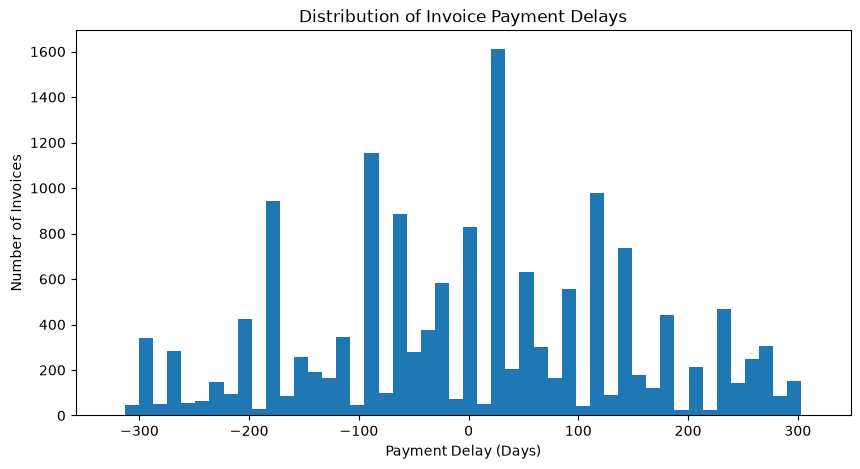

In [47]:
plt.figure(figsize=(10, 5))

plt.hist(
    paid['payment_delay_days'],
    bins=50
)

plt.xlabel('Payment Delay (Days)')
plt.ylabel('Number of Invoices')
plt.title('Distribution of Invoice Payment Delays')

plt.show()

In [48]:
print("Average delay:", paid['payment_delay_days'].mean())
print("Median delay:", paid['payment_delay_days'].median())

print("Severely late (>30 days):",
      (paid['payment_delay_days'] > 30).sum())

print("Very late (>60 days):",
      (paid['payment_delay_days'] > 60).sum())

print("Extremely late (>90 days):",
      (paid['payment_delay_days'] > 90).sum())

Average delay: 3.2686519372398335
Median delay: 5.0
Severely late (>30 days): 6607
Very late (>60 days): 5159
Extremely late (>90 days): 4340


In [49]:
customer_summary = (
    paid.groupby('cust_number')
    .agg(
        invoice_count=('doc_id', 'count'),
        avg_delay=('payment_delay_days', 'mean'),
        late_invoices=('payment_delay_days', lambda x: (x > 0).sum())
    )
)

customer_summary['late_rate'] = (
    customer_summary['late_invoices']
    / customer_summary['invoice_count']
)

customer_summary.sort_values(
    'late_rate',
    ascending=False
).head(10)

,invoice_count,avg_delay,late_invoices,late_rate
cust_number,,,,
200093491,1,266.0,1,1.0
140106257,1,242.0,1,1.0
140106302,1,33.0,1,1.0
140106343,2,109.5,2,1.0
140106358,1,29.0,1,1.0
140106376,1,30.0,1,1.0
140106379,5,68.0,5,1.0
140106434,1,174.0,1,1.0
200097356,1,265.0,1,1.0


In [50]:
customer_summary_10 = customer_summary[
    customer_summary['invoice_count'] >= 10
].sort_values(
    'late_rate',
    ascending=False
)

customer_summary_10.head(10)

,invoice_count,avg_delay,late_invoices,late_rate
cust_number,,,,
200508557,14,125.214286,12,0.857143
200780825,47,74.468085,37,0.787234
200833713,14,122.642857,11,0.785714
200778870,49,54.489796,37,0.755102
200186937,12,34.833333,9,0.750000
200943275,19,16.368421,14,0.736842
100030964,15,62.733333,11,0.733333
200622385,11,56.090909,8,0.727273
200770567,11,14.363636,8,0.727273


In [51]:
customer_summary_10.tail(10)

,invoice_count,avg_delay,late_invoices,late_rate
cust_number,,,,
200416837,140,-71.921429,46,0.328571
200721222,19,-69.210526,6,0.315789
200580232,13,-34.846154,4,0.307692
200742521,10,-64.200000,3,0.300000
200781831,11,-57.181818,2,0.181818
200712102,14,-106.285714,2,0.142857
CCU013,160,-101.750000,10,0.062500
CCCA02,121,-133.917355,0,0.000000
CCU001,13,-131.692308,0,0.000000


In [52]:
paid['cust_payment_terms'].value_counts().head(20)

cust_payment_terms
NAA8    6273
NAH4    4163
CA10    1217
NAM4     537
NAC6     496
NAAX     361
NAD1     338
NAU5     324
NAGD     236
NAG2     220
NA32     209
NAM2     195
NAX2     162
NA10     138
NAD5     104
NAM1      92
NAAW      74
NAVE      65
NAWU      49
NAVF      46
Name: count, dtype: int64

In [53]:
print(
    "Unique payment terms:",
    paid['cust_payment_terms'].nunique()
)

Unique payment terms: 53


In [54]:
terms = (
    paid.groupby('cust_payment_terms')
    .agg(
        invoices=('doc_id', 'count'),
        avg_delay=('payment_delay_days', 'mean'),
        late_invoices=('payment_delay_days', lambda x: (x > 0).sum())
    )
)

terms['late_rate'] = (
    terms['late_invoices'] / terms['invoices']
)

terms.sort_values(
    'invoices',
    ascending=False
).head(15)

,invoices,avg_delay,late_invoices,late_rate
cust_payment_terms,,,,
NAA8,6273,7.975450,3336,0.531803
NAH4,4163,12.564257,2315,0.556089
CA10,1217,9.304026,687,0.564503
NAM4,537,-128.677840,94,0.175047
NAC6,496,-13.973790,218,0.439516
NAAX,361,26.346260,214,0.592798
NAD1,338,25.210059,187,0.553254
NAU5,324,3.972222,171,0.527778
NAGD,236,5.707627,117,0.495763


In [55]:
terms_reliable = terms[terms['invoices'] >= 100].sort_values(
    'late_rate',
    ascending=False
)

terms_reliable.head(10)

,invoices,avg_delay,late_invoices,late_rate
cust_payment_terms,,,,
NAM2,195,105.620513,145,0.743590
NA10,138,31.021739,84,0.608696
NAD5,104,20.211538,63,0.605769
NAAX,361,26.346260,214,0.592798
CA10,1217,9.304026,687,0.564503
NAH4,4163,12.564257,2315,0.556089
NAD1,338,25.210059,187,0.553254
NA32,209,14.311005,112,0.535885
NAA8,6273,7.975450,3336,0.531803


In [56]:
result = terms[
    (terms["invoices"] >= 500) &
    (terms["late_rate"] >= 0.60)
].sort_values("late_rate", ascending=False)

print(result)

Empty DataFrame
Columns: [invoices, avg_delay, late_invoices, late_rate]
Index: []


In [57]:
paid["total_open_amount"].describe()

count     15615.000000
mean      32371.435333
std       39788.189610
min           5.680000
25%        4533.550000
50%       16970.920000
75%       47551.760000
max      668593.360000
Name: total_open_amount, dtype: float64

In [58]:
late_amount_median = paid[
    paid["payment_delay_days"] > 0
]["total_open_amount"].median()

ontime_amount_median = paid[
    paid["payment_delay_days"] <= 0
]["total_open_amount"].median()

print("Late invoice median:", late_amount_median)
print("On-time/early invoice median:", ontime_amount_median)

Late invoice median: 17078.79
On-time/early invoice median: 16930.48


In [59]:
paid["late_payment"] = (
    paid["payment_delay_days"] > 0
).astype(int)

In [60]:
paid["late_payment"].value_counts()

late_payment
1    8129
0    7486
Name: count, dtype: int64

In [61]:
paid["invoice_year"] = paid["posting_date"].dt.year

yearly_late_rate = (
    paid.groupby("invoice_year")["late_payment"]
    .mean() * 100
)

print(yearly_late_rate)

Series([], Name: late_payment, dtype: float64)


In [62]:
print("paid rows:", len(paid))
print(paid["posting_date"].head())
print(paid["invoice_year"].head())

paid rows: 15615
0   NaT
1   NaT
5   NaT
6   NaT
9   NaT
Name: posting_date, dtype: datetime64[s]
0   NaN
1   NaN
5   NaN
6   NaN
9   NaN
Name: invoice_year, dtype: float64


In [64]:
import os
os.makedirs('../data/processed', exist_ok=True)

df.to_csv('../data/processed/cleaned.csv', index=False)

In [65]:
# Cell 1: Final Cleaning
df = df.drop_duplicates()
df = df.drop(columns=['area_business','document_create_date.1'], errors='ignore')
df['clear_date'] = pd.to_datetime(df['clear_date'], errors='coerce')
df['posting_date'] = pd.to_datetime(df['posting_date'])
df['due_in_date'] = pd.to_datetime(df['due_in_date'].astype(str).str.split('.').str[0], format='%Y%m%d', errors='coerce')
df['is_delayed'] = (df['clear_date'] > df['due_in_date']).astype('Int64')
df['is_delayed'] = df['is_delayed'].fillna(1)
df['delay_days'] = (df['clear_date'] - df['due_in_date']).dt.days
df['delay_days'] = df['delay_days'].fillna(999)
df.to_csv('../data/processed/cleaned.csv', index=False)

# Cell 2: Push to Postgres (YE TERA SQL KAAM HAI)
from sqlalchemy import text
df.to_sql('invoices', engine, if_exists='replace', index=False)
print("Done")

Done


In [66]:
import pandas as pd
from sqlalchemy import create_engine, URL

# Load cleaned data
df = pd.read_csv('../data/processed/cleaned.csv')

# Connect
engine = create_engine(URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password="Mypassword",
    host="localhost",
    port=5432,
    database="sme_payment_risk"
))

# Push - ye tera main SQL ka kaam hai
df.to_sql('invoices', engine, if_exists='replace', index=False)
print(f"Done! {len(df)} rows pushed to Postgres")

Done! 48839 rows pushed to Postgres


In [67]:
import pandas as pd
from sqlalchemy import create_engine, URL

df = pd.read_csv('../data/processed/cleaned.csv')

# is_delayed column agar cleaned me nahi hai to bana lete hain
if 'is_delayed' not in df.columns:
    # maan lete hain agar clear_date > due_date hai toh delayed = 1
    df['clear_date'] = pd.to_datetime(df['clear_date'], errors='coerce')
    df['due_date'] = pd.to_datetime(df['due_date'], errors='coerce')
    df['is_delayed'] = (df['clear_date'] > df['due_date']).astype(int)
    df['is_delayed'] = df['is_delayed'].fillna(1) # open invoices ko risky maan lete hain

engine = create_engine(URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password="Mypassword",
    host="localhost",
    port=5432,
    database="sme_payment_risk"
))

df.to_sql('invoices', engine, if_exists='replace', index=False)
print(f"✅ DONE - {len(df)} rows pushed, ab dashboard me data dikhega")

✅ DONE - 48839 rows pushed, ab dashboard me data dikhega
